In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

from config import *

sns.set_style("darkgrid")

In [2]:
df = pd.read_parquet("../data/stats_dataset.parquet")
df.tail()

,fen,next_move,played_by_elo,win_pov,games_count,engine_move,delta,fragility_score,variance,group_count_500,...,historical_top3_2300,is_historical_top3_2300,group_count_2400,winrate_2400,historical_best_2400,is_historical_best_2400,historical_top2_2400,is_historical_top2_2400,historical_top3_2400,is_historical_top3_2400
1001886,rnbqkbnr/pppppppp/8/8/3P4/8/PPP1PPPP/RNBQKBNR ...,d7d5,1834,False,145903,g8f6,0.284366,-0.788823,-0.174046,176.0,...,[d7d5],True,1345.0,0.457249,[d7d5],True,[d7d5],True,[d7d5],True
1001887,rnbqkbnr/ppp1pppp/8/3p4/3P4/8/PPP1PPPP/RNBQKBN...,c1f4,1835,True,145903,c2c4,-0.612085,-0.807181,-0.156649,173.0,...,[c1f4],True,1307.0,0.537873,[c1f4],True,[c1f4],True,[c1f4],True
1001888,rnbqkbnr/ppp1pppp/8/3p4/3P1B2/8/PPP1PPPP/RN1QK...,c7c6,1834,False,10250,e7e6,-0.845942,-0.715394,-0.169172,6.0,...,"[d8d7, b7b6, c8g4]",False,291.0,0.422680,[b7b6],False,"[b7b6, b8d7]",False,"[b7b6, b8d7, c8g4]",False
1001889,rnbqkbnr/pp2pppp/2p5/3p4/3P1B2/8/PPP1PPPP/RN1Q...,g1f3,1835,True,2449,e2e3,-0.495157,-0.109598,-0.132579,NaN,...,"[g1f3, e2e3, c2c3]",True,20.0,0.450000,[b1c3],False,"[b1c3, c2c3]",False,"[b1c3, c2c3, e2e3]",False
1001890,rnbqkbnr/pp2pppp/2p5/3p4/3P1B2/5N2/PPP1PPPP/RN...,c8g4,1834,False,156,c8f5,-1.001847,-0.036168,-0.159541,NaN,...,"[e7e6, g8f6, c8f5]",False,1.0,1.000000,[c8g4],True,"[c8g4, g8f6]",True,"[c8g4, g8f6, c8f5]",True


## Feature Coefficients

In [3]:
coefficients = pd.DataFrame(index=FEATURES)
p_values = pd.DataFrame(index=FEATURES)

for elo in ELOS:
    target = f'is_historical_best_{elo}'
    subset = df.dropna(subset=FEATURES + [target])
    X = sm.add_constant(subset[FEATURES])
    y = subset[target].astype(int)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, random_state=1, test_size=0.25
    )

    model = sm.Logit(y_train, X_train)
    result = model.fit(disp=0)
    coefficients[f'elo_{elo}'] = result.params
    p_values[f'elo_{elo}'] = result.pvalues

coefficients

,elo_500,elo_600,elo_700,elo_800,elo_900,elo_1000,elo_1100,elo_1200,elo_1300,elo_1400,elo_1500,elo_1600,elo_1700,elo_1800,elo_1900,elo_2000,elo_2100,elo_2200,elo_2300,elo_2400
delta,0.022641,0.032051,0.097773,-0.017682,0.016562,0.002182,0.062258,-0.023620,0.002598,0.072429,0.045370,0.065245,0.068578,-0.021056,0.033048,-0.009153,-0.036916,0.013709,0.054301,0.083259
fragility_score,-1.190073,-0.995991,-0.611649,-0.526089,-0.652304,-0.579410,-0.445483,-0.565279,-0.361674,-0.573906,-0.638433,-0.600258,-0.592133,-0.613269,-0.558487,-0.527589,-0.431422,-0.559113,-0.820009,-0.705385
variance,-1.207368,-0.072539,0.008983,0.074131,0.076628,0.016895,0.062537,0.117375,-0.006362,0.344040,0.139951,0.216702,0.190025,0.127715,0.105512,0.103815,0.080435,0.071977,-0.058350,-0.764179


In [4]:
# Significance (p-value < 0.05)
p_values < 0.05

,elo_500,elo_600,elo_700,elo_800,elo_900,elo_1000,elo_1100,elo_1200,elo_1300,elo_1400,elo_1500,elo_1600,elo_1700,elo_1800,elo_1900,elo_2000,elo_2100,elo_2200,elo_2300,elo_2400
delta,True,True,True,True,True,False,True,True,False,True,True,True,True,True,True,True,True,True,True,True
fragility_score,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
variance,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True


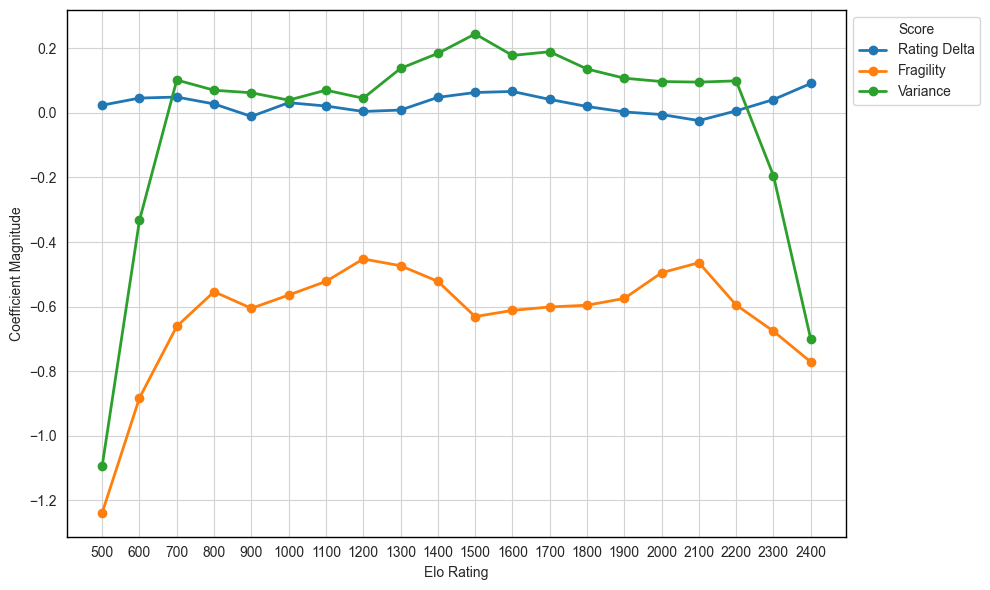

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor("white")

for feature in FEATURES:
    y = coefficients.loc[feature, coefficients.columns].values
    y_smooth = savgol_filter(y, window_length=5, polyorder=2)
    plt.plot(ELOS, y_smooth, marker='o', linewidth=2, label=FEATURE_LABELS.get(feature, feature))

ax.set_axisbelow(True)
ax.grid(True, color="lightgray")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)
ax.set_xlabel("Elo Rating")
ax.set_ylabel("Coefficient Magnitude")
plt.xticks(ELOS)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1),
    title="Score",
    facecolor="white"
)
fig.tight_layout()
fig.savefig("../images/feature_coefficients.pdf")
plt.show()

## Feature Importance

In [6]:
importances = pd.DataFrame(index=FEATURES)

for elo in ELOS:
    target = f'is_historical_best_{elo}'
    subset = df.dropna(subset=FEATURES + [target])
    X = subset[FEATURES]
    y = subset[target].astype(int)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, random_state=1, test_size=0.25
    )

    model = XGBClassifier(eval_metric='logloss')
    model.fit(X_train, y_train)
    importances[f'elo_{elo}'] = model.feature_importances_

importances

,elo_500,elo_600,elo_700,elo_800,elo_900,elo_1000,elo_1100,elo_1200,elo_1300,elo_1400,elo_1500,elo_1600,elo_1700,elo_1800,elo_1900,elo_2000,elo_2100,elo_2200,elo_2300,elo_2400
delta,0.178966,0.126053,0.134018,0.146020,0.155822,0.172453,0.159209,0.166006,0.142673,0.148609,0.196733,0.187073,0.155748,0.163223,0.150624,0.141355,0.138769,0.142601,0.142613,0.146129
fragility_score,0.548919,0.563955,0.588362,0.594279,0.606905,0.550153,0.566110,0.562224,0.580287,0.500986,0.535687,0.588055,0.529551,0.561995,0.593299,0.600500,0.594355,0.613505,0.587614,0.585667
variance,0.272116,0.309993,0.277620,0.259700,0.237273,0.277394,0.274681,0.271770,0.277040,0.350405,0.267580,0.224872,0.314701,0.274781,0.256077,0.258144,0.266876,0.243895,0.269772,0.268204


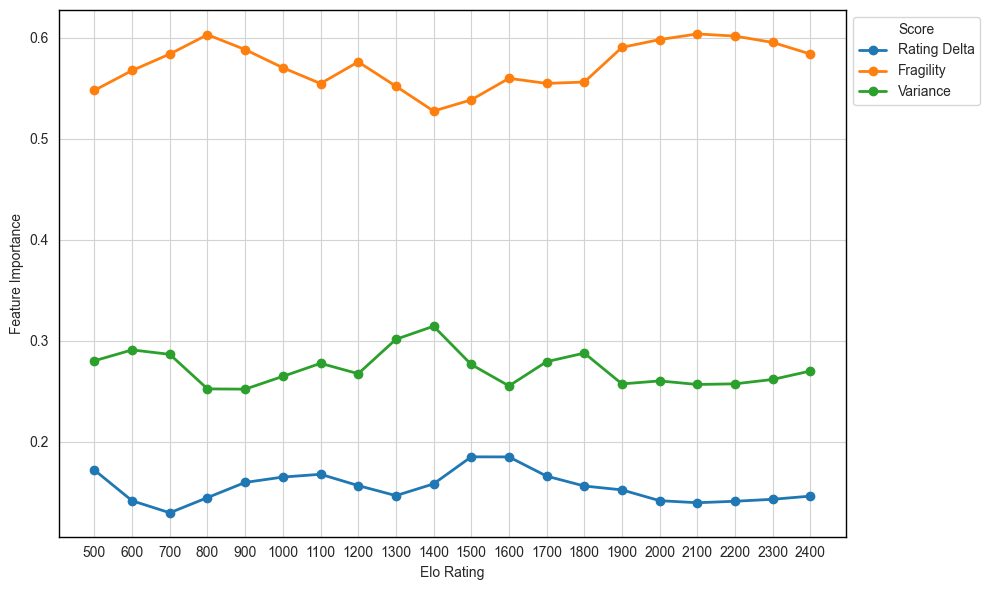

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor("white")

for feature in FEATURES:
    y = importances.loc[feature, importances.columns].values
    y_smooth = savgol_filter(y, window_length=5, polyorder=2)
    ax.plot(ELOS, y_smooth, marker='o', linewidth=2, label=FEATURE_LABELS.get(feature, feature))

ax.set_axisbelow(True)
ax.grid(True, color="lightgray")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)
ax.set_xlabel("Elo Rating")
ax.set_ylabel("Feature Importance")
ax.set_xticks(ELOS)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1),
    title="Score",
    facecolor="white"
)
fig.tight_layout()
fig.savefig("../images/feature_importance.pdf")
plt.show()

## Score Function and Move Recommendation

In [8]:
for elo in ELOS:
    elo_col = f"elo_{elo}"
    score_col = f"score_{elo}"
    rec_col = f"recommended_move_{elo}"
    is_best_col = f"is_best_{elo}"
    is_top2_col = f"is_top2_{elo}"
    is_top3_col = f"is_top3_{elo}"
    is_engine1_col = f"is_engine_best_{elo}"
    is_engine2_col = f"is_engine_top2_{elo}"
    is_engine3_col = f"is_engine_top3_{elo}"
    hist_best_col = f"historical_best_{elo}"
    hist_top2_col = f"historical_top2_{elo}"
    hist_top3_col = f"historical_top3_{elo}"

    # Score function
    df[score_col] = (
            coefficients.loc["delta", elo_col] * df["delta"] +
            coefficients.loc["fragility_score", elo_col] * df["fragility_score"] +
            coefficients.loc["variance", elo_col] * df["variance"]
    )

    # Determine the recommended move per FEN based on the score
    idx_best = df.groupby('fen')[score_col].idxmax().dropna().astype(int)
    recommended = df.loc[idx_best, ['fen', 'next_move']].set_index('fen')['next_move']
    df[rec_col] = df['fen'].map(recommended)

    # Top-Flags
    df[is_best_col] = df.apply(lambda r: r[rec_col] in r[hist_best_col], axis=1).astype('boolean')
    if hist_top2_col in df.columns:
        df[is_top2_col] = df.apply(lambda r: r[rec_col] in r[hist_top2_col], axis=1).astype('boolean')
    else:
        df[is_top2_col] = pd.NA
    if hist_top3_col in df.columns:
        df[is_top3_col] = df.apply(lambda r: r[rec_col] in r[hist_top3_col], axis=1).astype('boolean')
    else:
        df[is_top3_col] = pd.NA

    # Engine-Flags
    df[is_engine1_col] = df.apply(lambda r: r['engine_move'] in r[hist_best_col], axis=1).astype('boolean')
    if hist_top2_col in df.columns:
        df[is_engine2_col] = df.apply(lambda r: r['engine_move'] in r[hist_top2_col], axis=1).astype('boolean')
    else:
        df[is_engine2_col] = pd.NA
    if hist_top3_col in df.columns:
        df[is_engine3_col] = df.apply(lambda r: r['engine_move'] in r[hist_top3_col], axis=1).astype('boolean')
    else:
        df[is_engine3_col] = pd.NA

    # # Mask out positions with too few samples or missing data
    # invalid_mask = (
    #         (df[group_count_col] < MIN_SAMPLES_PER_GROUP) |
    #         (df[group_count_col].isna())
    # )
    # df.loc[invalid_mask, [is_best_col, is_engine_col]] = pd.NA

    # Exclude rows where engine move is not among the observed moves for that position
    valid_moves = df.groupby('fen')['next_move'].agg(set).to_dict()
    df['engine_valid_move'] = df.apply(
        lambda r: r['engine_move'] in valid_moves.get(r['fen'], set()), axis=1
    )
    df.loc[~df['engine_valid_move'], [is_engine1_col, is_engine2_col, is_engine3_col]] = pd.NA
    df.drop(columns='engine_valid_move', inplace=True)

In [9]:
df.to_parquet("../data/recommendation_dataset.parquet", index=False)
print("✅ Saved enriched dataset to 'data/recommendation_dataset.parquet'")

✅ Saved enriched dataset to 'data/recommendation_dataset.parquet'


# TEST

In [10]:
results = []
grouped = df.groupby("fen").first().reset_index()

for elo in ELOS:
    is_best_col = f"is_best_{elo}"
    is_engine_col = f"is_engine_best_{elo}"

    avg_is_best = grouped[is_best_col].mean()
    avg_is_engine_best = grouped[is_engine_col].mean()

    results.append({
        "elo": elo,
        "avg_is_best": avg_is_best,
        "avg_is_engine_best": avg_is_engine_best
    })

results = pd.DataFrame(results).set_index("elo")
results

,avg_is_best,avg_is_engine_best
elo,,
500,0.098418,0.128134
600,0.265378,0.292479
700,0.502636,0.523677
800,0.662566,0.604457
900,0.729350,0.701950
1000,0.766257,0.729805
1100,0.801406,0.743733
1200,0.780316,0.707521
1300,0.785589,0.715877


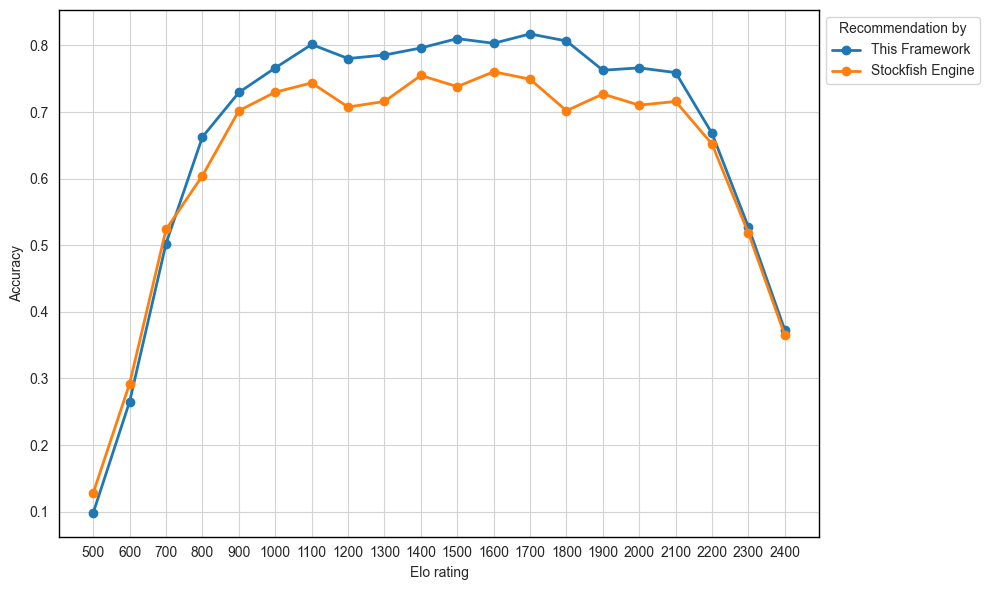

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor("white")

for col in results.columns:
    if col == "avg_is_best":
        label = "This Framework"
    else:
        label = "Stockfish Engine"
    ax.plot(results.index, results[col].values, marker='o', linewidth=2, label=label)

ax.set_axisbelow(True)
ax.grid(True, color="lightgray")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)
ax.set_xlabel("Elo rating")
ax.set_ylabel("Accuracy")
ax.set_xticks(results.index)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1),
    title="Recommendation by",
    facecolor="white"
)
fig.tight_layout()
fig.savefig("../images/prediction_accuracy.pdf")
plt.show()

In [12]:
results = []
grouped = df.groupby("fen").first().reset_index()

for elo in ELOS:
    # Spaltennamen
    is_best_col = f"is_best_{elo}"
    is_top2_col = f"is_top2_{elo}"
    is_top3_col = f"is_top3_{elo}"
    is_engine1_col = f"is_engine_best_{elo}"
    is_engine2_col = f"is_engine_top2_{elo}"
    is_engine3_col = f"is_engine_top3_{elo}"

    # Gewichtet Mittelwerte
    wa_best = grouped[is_best_col].mean()
    wa_top2 = grouped[is_top2_col].mean()
    wa_top3 = grouped[is_top3_col].mean()
    wa_eng1 = grouped[is_engine1_col].mean()
    wa_eng2 = grouped[is_engine2_col].mean()
    wa_eng3 = grouped[is_engine3_col].mean()

    results.append({
        "elo": elo,
        "avg_is_best": wa_best,
        "avg_is_top2": wa_top2,
        "avg_is_top3": wa_top3,
        "avg_is_engine_best": wa_eng1,
        "avg_is_engine_top2": wa_eng2,
        "avg_is_engine_top3": wa_eng3
    })

results = pd.DataFrame(results).set_index("elo")
results

,avg_is_best,avg_is_top2,avg_is_top3,avg_is_engine_best,avg_is_engine_top2,avg_is_engine_top3
elo,,,,,,
500,0.098418,0.101933,0.103691,0.128134,0.130919,0.142061
600,0.265378,0.284710,0.300527,0.292479,0.331476,0.353760
700,0.502636,0.539543,0.565905,0.523677,0.593315,0.618384
800,0.662566,0.745167,0.780316,0.604457,0.701950,0.757660
900,0.729350,0.848858,0.889279,0.701950,0.813370,0.883008
1000,0.766257,0.876977,0.924429,0.729805,0.827298,0.899721
1100,0.801406,0.899824,0.940246,0.743733,0.849582,0.919220
1200,0.780316,0.887522,0.934974,0.707521,0.849582,0.927577
1300,0.785589,0.891037,0.934974,0.715877,0.816156,0.896936


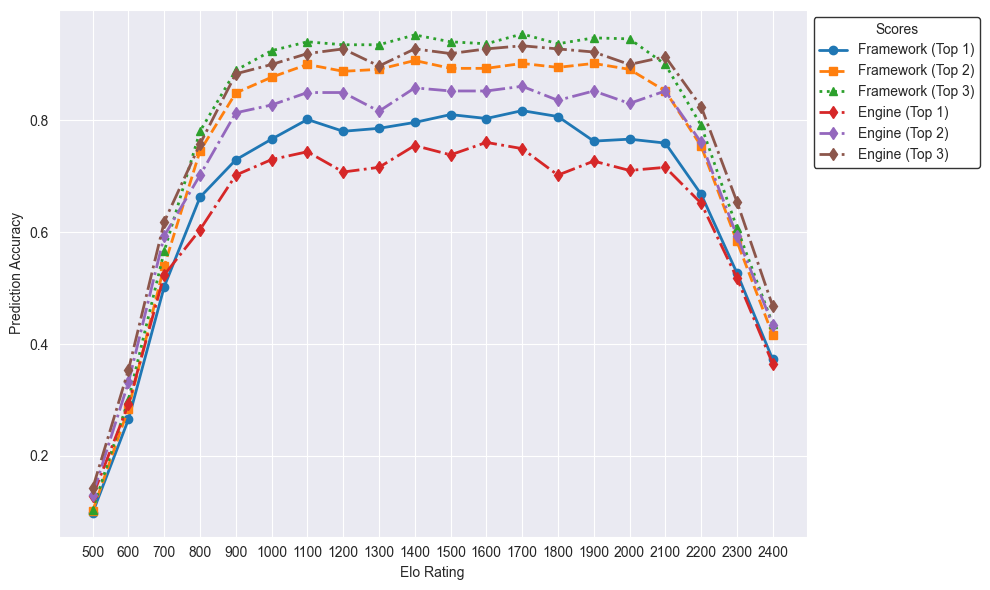

In [13]:
plt.figure(figsize=(10, 6))

plt.plot(results.index, results["avg_is_best"].values, marker="o", linewidth=2, label="Framework (Top 1)")
plt.plot(results.index, results["avg_is_top2"].values, marker="s", linestyle="--", linewidth=2,
         label="Framework (Top 2)")
plt.plot(results.index, results["avg_is_top3"].values, marker="^", linestyle=":", linewidth=2,
         label="Framework (Top 3)")

# Engine Top-K
plt.plot(results.index, results["avg_is_engine_best"].values, marker="d", linestyle="-.", linewidth=2,
         label="Engine (Top 1)")
plt.plot(results.index, results["avg_is_engine_top2"].values, marker="d", linestyle="-.", linewidth=2,
         label="Engine (Top 2)")
plt.plot(results.index, results["avg_is_engine_top3"].values, marker="d", linestyle="-.", linewidth=2,
         label="Engine (Top 3)")

plt.xlabel("Elo Rating")
plt.ylabel("Prediction Accuracy")
plt.xticks(results.index)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1), title="Scores", facecolor="white", edgecolor="black")
plt.tight_layout()
plt.savefig("../images/prediction_accuracy_topk.pdf", bbox_inches="tight")
plt.show()


# was anners

In [14]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Feature engineering
df["f_cross_d"] = df["fragility_score"] * df["delta"]
df["f_cross_v"] = df["fragility_score"] * df["variance"]
df["d_cross_v"] = df["delta"] * df["variance"]

target_columns = [col for col in df.columns if col.startswith("is_best_") or col.startswith("is_engine_best_")]

for y_feature in target_columns:
    print(f"{y_feature}:")
    df_reg = df[pd.notna(df[y_feature])]  # Remove NaN values

    # Ensure we have both classes (True and False) in the target variable
    if df_reg[y_feature].nunique() < 2:
        print("Skipping due to only one class in the target variable.")
        continue

    selected_features = ["fragility_score", "delta", "variance", "f_cross_d", "f_cross_v", "d_cross_v"]
    X = df_reg[selected_features]
    y = df_reg[y_feature].astype(bool)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=1, stratify=y
    )

    # Logistic Regression
    log_model = LogisticRegression()
    log_model.fit(X_train, y_train)
    y_pred_log = log_model.predict(X_test)
    acc_log = accuracy_score(y_test, y_pred_log)
    print(f"Logistic Regression Accuracy: {acc_log * 100:.1f} %")

    # XGBoost
    xgb_model = XGBClassifier()
    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test)
    acc_xgb = accuracy_score(y_test, y_pred_xgb)
    print(f"XGBoost Accuracy: {acc_xgb * 100:.1f} %")
    print()


is_best_500:
Logistic Regression Accuracy: 86.3 %
XGBoost Accuracy: 100.0 %

is_engine_best_500:
Logistic Regression Accuracy: 76.4 %
XGBoost Accuracy: 100.0 %

is_best_600:
Logistic Regression Accuracy: 86.4 %
XGBoost Accuracy: 100.0 %

is_engine_best_600:
Logistic Regression Accuracy: 79.1 %
XGBoost Accuracy: 99.9 %

is_best_700:
Logistic Regression Accuracy: 83.4 %
XGBoost Accuracy: 100.0 %

is_engine_best_700:
Logistic Regression Accuracy: 76.1 %
XGBoost Accuracy: 99.8 %

is_best_800:
Logistic Regression Accuracy: 75.3 %
XGBoost Accuracy: 99.9 %

is_engine_best_800:
Logistic Regression Accuracy: 84.7 %
XGBoost Accuracy: 99.8 %

is_best_900:
Logistic Regression Accuracy: 66.4 %
XGBoost Accuracy: 100.0 %

is_engine_best_900:
Logistic Regression Accuracy: 78.6 %
XGBoost Accuracy: 100.0 %

is_best_1000:
Logistic Regression Accuracy: 73.6 %
XGBoost Accuracy: 100.0 %

is_engine_best_1000:
Logistic Regression Accuracy: 80.8 %
XGBoost Accuracy: 99.9 %

is_best_1100:
Logistic Regression Acc

# stacked linechart

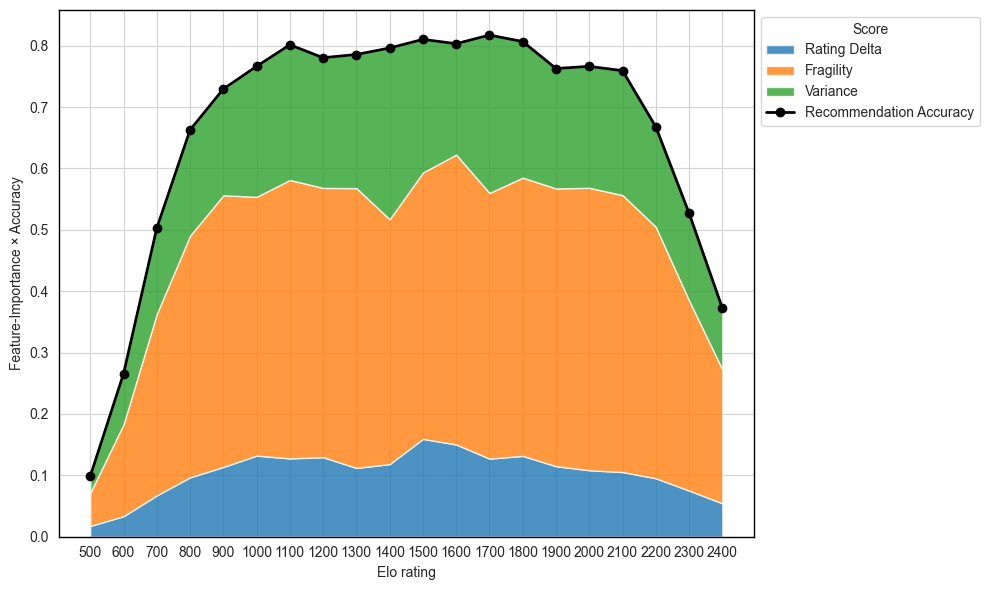

In [15]:
import matplotlib.pyplot as plt

# 1. Spaltennamen von 'importances' in Integer-Elo umwandeln,
#    falls sie das Format "elo_1000", "elo_1100" o. Ä. haben.
#    Beispiel: "elo_1000" → 1000
if importances.columns.dtype == object:
    importances.columns = (
        importances.columns
        .astype(str)
        .str.extract(r"(\d+)", expand=False)
        .astype(int)
    )

# 2. Index von 'results' ebenfalls in Integer-Elo umwandeln,
#    falls er z. B. "elo_1000", "elo_1100" o. Ä. enthält.
if results.index.dtype == object:
    results.index = (
        results.index
        .astype(str)
        .str.extract(r"(\d+)", expand=False)
        .astype(int)
    )

# 3. Transponiere 'importances', sodass jede Zeile eine Elo-Stufe ist,
#    und reindexiere auf dieselben Elo-Werte wie 'results'.
fi_df = importances.T.reindex(results.index).fillna(0)

# 4. Hole die Framework-Accuracy („avg_is_best“) als Array
y_acc = results["avg_is_best"].reindex(fi_df.index).fillna(0).values

# 5. Berechne für jedes Feature den Beitrag: feature_importance × accuracy
feature_arrays = []
feature_labels = {
    "fragility_score": "Fragility",
    "delta": "Rating Delta",
    "variance": "Variance"
}
for feat in FEATURES:
    arr = fi_df[feat].values * y_acc
    feature_arrays.append(arr)

# 6. Zeichne das gestapelte Flächen-Diagramm unterhalb der Accuracy-Linie
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor("white")

ax.stackplot(
    fi_df.index,
    *feature_arrays,
    labels=[feature_labels[f] for f in FEATURES],
    alpha=0.8
)
ax.plot(
    fi_df.index,
    y_acc,
    color="black",
    marker="o",
    linewidth=2,
    label="Recommendation Accuracy"
)

ax.set_axisbelow(True)
ax.grid(True, color="lightgray")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)
ax.set_xlabel("Elo rating")
ax.set_ylabel("Feature-Importance × Accuracy")
ax.set_xticks(fi_df.index)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1, 1),
    title="Score",
    facecolor="white"
)
fig.tight_layout()
fig.savefig("../images/feature_importance.pdf")
plt.show()